In [32]:
#import the libraries
import pandas as pd
import numpy as np
import csv
from sklearn import svm, model_selection
from matplotlib import pyplot as plt

In [ ]:
#read the file
file_path = "creditcard.csv"
data = pd.read_csv(file_path)

In [ ]:
#split the data into features X and target Y 
X = data.drop(columns=["Time", "Amount", "Class"])
Y = data["Class"]

#test split the data
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, test_size=0.2)

In [ ]:
def experiment(c=1):

    #I am using SVC method with rbf kernel
    model = svm.SVC(C=c)

    #fit the model and make a prediciton
    result = model.fit(X_train, Y_train)
    prediction = result.predict(X_test)
    return prediction

prediction = experiment()

In [69]:
#create contigency table to see the results
table = pd.crosstab(prediction, Y_test, margins=True, rownames=["Predicted"], colnames=["Actual"])
print(table)

TP = table.loc[1, 1]
TN = table.loc[0, 0]
FP = table.loc[1, 0]
FN = table.loc[0, 1]

print(TP, TN, FP, FN)

Actual         0   1    All
Predicted                  
0          56874  27  56901
1              1  60     61
All        56875  87  56962
60 56874 1 27


In [87]:
#calculating the most important measures
def accuracy():
    return round(TP+TN/(TP+TN+FP+FN), 2)

def specificity():
    return round(TN/(TN + FP), 2)

def precision():
    return round(TP/(TP + FP), 2)

def recall():
    return round(TP/(TP + FN), 2)

def F1():
    return round(2 * (recall() * precision()) / (recall() + precision()), 2)

print(f"Accuracy: {accuracy()}")
print(f"Specificity: {specificity()}")
print(f"Precision: {precision()}")
print(f"Recall: {recall()}")
print(f"F1: {F1()}")


Accuracy: 61.0
Specificity: 1.0
Precision: 0.98
Recall: 0.69
F1: 0.81


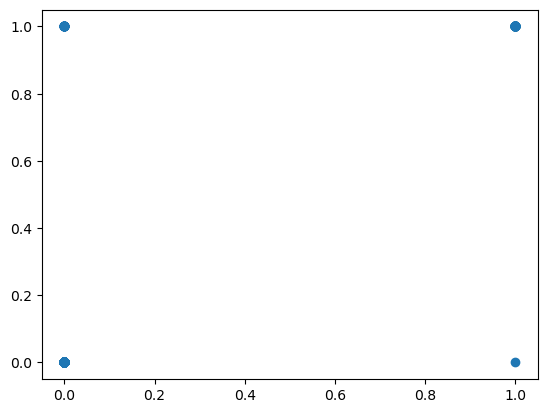

In [ ]:
for c in range(0, 8):
    prediction = experiment(c)
    